# Spectral graph theory :

In [1]:
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np
import matplotlib
from PIL import Image

In [2]:
n = 12  
m = 20  
G = nx.gnm_random_graph(n, m, seed=42)  

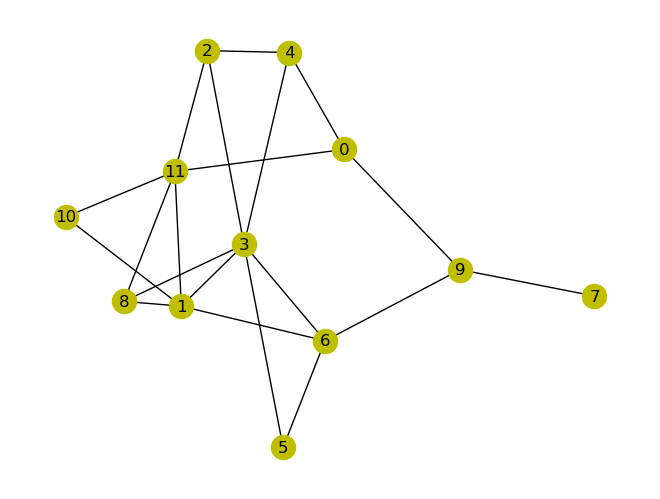

In [16]:
my_pose  = nx.spring_layout(G)
nx.draw(G,alpha=1,node_color = 'y',pos=my_pose, with_labels = True)

We will use this graph G as exemple to experiment spectal graph theory.

### 1) Laplacian matrix :
   a) With the adjacency matrix and the degree matrix of G, compute the Laplacian Matrix $L$ and the normalized Laplacian $L_{norm}$.

In [46]:
A = nx.adjacency_matrix(G).toarray()
A

array([[0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 1],
       [0, 0, 0, 1, 0, 0, 1, 0, 1, 0, 1, 1],
       [0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 1],
       [0, 1, 1, 0, 1, 1, 1, 0, 1, 0, 0, 0],
       [1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0],
       [0, 1, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0],
       [0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1],
       [1, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0],
       [0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1],
       [1, 1, 1, 0, 0, 0, 0, 0, 1, 0, 1, 0]])

In [51]:
deg_noeuds = [G.degree(n) for n in G.nodes()]
deg_noeuds
D = np.diag(deg_noeuds)
D_inv_sqrt = np.linalg.inv(np.sqrt(D))
D_inv_sqrt

array([[0.57735027, 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        ],
       [0.        , 0.4472136 , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        ],
       [0.        , 0.        , 0.57735027, 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        ],
       [0.        , 0.        , 0.        , 0.40824829, 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        ],
       [0.        , 0.        , 0.        , 0.        , 0.57735027,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        ],
       [0.        , 0.        , 0.        , 0.        , 0.        ,
        0.70710678, 0.        , 0.        , 0.        , 0.        ,
        0.        ,

In [74]:
I = np.eye(D.shape[0])
I

array([[1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1.]])

In [53]:
L =  D - A
L

array([[ 3,  0,  0,  0, -1,  0,  0,  0,  0, -1,  0, -1],
       [ 0,  5,  0, -1,  0,  0, -1,  0, -1,  0, -1, -1],
       [ 0,  0,  3, -1, -1,  0,  0,  0,  0,  0,  0, -1],
       [ 0, -1, -1,  6, -1, -1, -1,  0, -1,  0,  0,  0],
       [-1,  0, -1, -1,  3,  0,  0,  0,  0,  0,  0,  0],
       [ 0,  0,  0, -1,  0,  2, -1,  0,  0,  0,  0,  0],
       [ 0, -1,  0, -1,  0, -1,  4,  0,  0, -1,  0,  0],
       [ 0,  0,  0,  0,  0,  0,  0,  1,  0, -1,  0,  0],
       [ 0, -1,  0, -1,  0,  0,  0,  0,  3,  0,  0, -1],
       [-1,  0,  0,  0,  0,  0, -1, -1,  0,  3,  0,  0],
       [ 0, -1,  0,  0,  0,  0,  0,  0,  0,  0,  2, -1],
       [-1, -1, -1,  0,  0,  0,  0,  0, -1,  0, -1,  5]])

In [65]:
Lnorm = I - D_inv_sqrt @ A @ D_inv_sqrt
Lnorm[:5,:]

array([[ 1.        ,  0.        ,  0.        ,  0.        , -0.33333333,
         0.        ,  0.        ,  0.        ,  0.        , -0.33333333,
         0.        , -0.25819889],
       [ 0.        ,  1.        ,  0.        , -0.18257419,  0.        ,
         0.        , -0.2236068 ,  0.        , -0.25819889,  0.        ,
        -0.31622777, -0.2       ],
       [ 0.        ,  0.        ,  1.        , -0.23570226, -0.33333333,
         0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
         0.        , -0.25819889],
       [ 0.        , -0.18257419, -0.23570226,  1.        , -0.23570226,
        -0.28867513, -0.20412415,  0.        , -0.23570226,  0.        ,
         0.        ,  0.        ],
       [-0.33333333,  0.        , -0.33333333, -0.23570226,  1.        ,
         0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
         0.        ,  0.        ]])

b) You will now perform an eigendecomposition of $L_{norm} = U \lambda U^T$.
Explain what is $U$ and what is $\lambda$.

In [75]:
# U is the matrix of eigenvectors, where each column corresponds to an eigenvector of L_norm.
# λ (lambda) is the diagonal matrix of eigenvalues, where each diagonal entry corresponds to an eigenvalue of L_norm.
# np.linalg.eigh returns the eigenvalues and eigenvectors of a symmetric (Hermitian) matrix.
eigenvalues, eigenvectors = np.linalg.eigh(Lnorm)
# eigenvalues = np.real(eigenvalues)
# eigenvectors = np.real(eigenvectors)
idx = eigenvalues.argsort()
eigenvalues = eigenvalues[idx]
eigenvectors = eigenvectors[:, idx]

c) Plot the histogram of eigenvalues and verify they are between 0 and 2, why? How many are they?

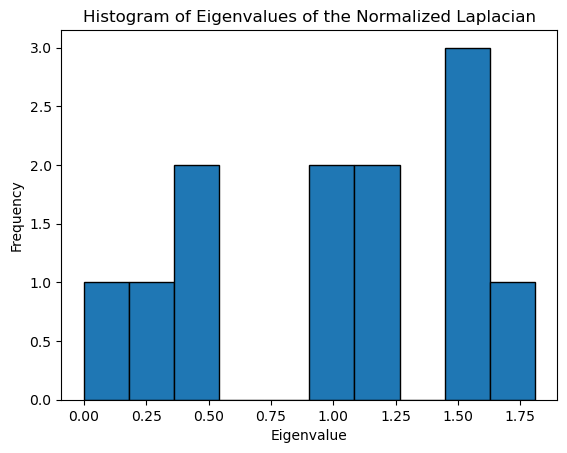

In [76]:
# histogram of eigenvalues
plt.figure()
plt.hist(eigenvalues, bins=10, edgecolor='black')
plt.title("Histogram of Eigenvalues of the Normalized Laplacian")
plt.xlabel("Eigenvalue")
plt.ylabel("Frequency")
plt.show()

### 2) Graph filtering :

To visualize effects of filtering, we will define a very simple signal H on the nodes of G

signal :  [ 0.  0.  0.  0.  0.  0. 10.  0.  0.  0. 10.  0.]


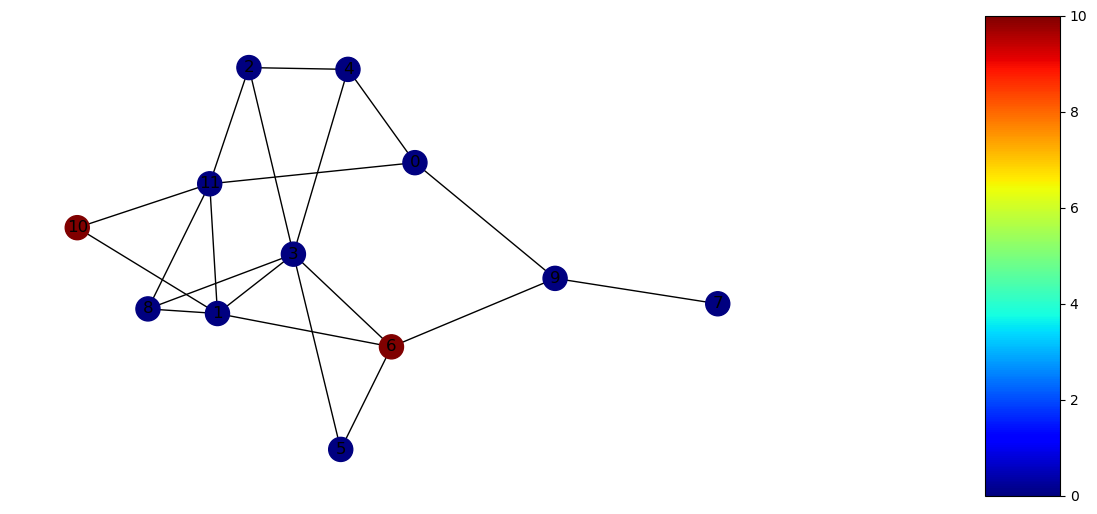

In [77]:
H= np.zeros(n)
H[6]=10
H[10]=10
print("signal : ", H)
vmin=np.min(H)
vmax=np.max(H)
fig,ax1 = plt.subplots(1,1,figsize=(10,6))
nx.draw(G,alpha=1,node_color=H,pos=my_pose,vmin=vmin,vmax=vmax,cmap='jet', ax=ax1,with_labels = True)
cax = plt.axes([1.1, 0.1, 0.075, 0.8])
plt.colorbar( matplotlib.cm.ScalarMappable(norm=plt.Normalize(vmin=vmin,vmax=vmax), cmap='jet'), ax=ax1,orientation="vertical",cax=cax)


Implement and visualize the filtering of G by the two filters below. What did you observe? Comment the results.

High-pass filter  :  [0.  0.  0.  0.  0.  0.  1.3 1.3 1.3 1.3 1.3 1.3]
Low-pass filter  :  [0.7 0.7 0.7 0.7 0.7 0.7 0.  0.  0.  0.  0.  0. ]


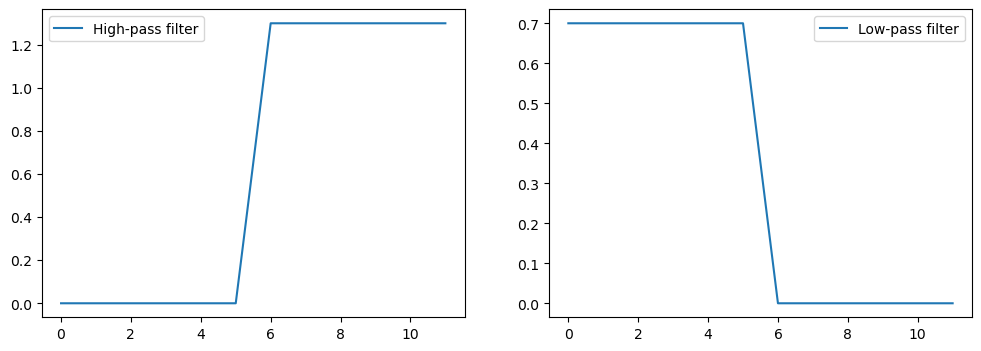

In [78]:
HF = 1.3*np.ones(n)
HF[:6]=0
print("High-pass filter  : ",HF)
LF = np.zeros(n)
LF[:6]=0.7
print("Low-pass filter  : ",LF)
fig,(ax1, ax2) = plt.subplots(1,2,figsize=(12,4))
ax1.plot(HF,label = 'High-pass filter')
ax2.plot(LF, label = 'Low-pass filter')
ax1.legend()
ax2.legend()

In [80]:
np.diag(HF)

array([[0. , 0. , 0. , 0. , 0. , 0. , 0. , 0. , 0. , 0. , 0. , 0. ],
       [0. , 0. , 0. , 0. , 0. , 0. , 0. , 0. , 0. , 0. , 0. , 0. ],
       [0. , 0. , 0. , 0. , 0. , 0. , 0. , 0. , 0. , 0. , 0. , 0. ],
       [0. , 0. , 0. , 0. , 0. , 0. , 0. , 0. , 0. , 0. , 0. , 0. ],
       [0. , 0. , 0. , 0. , 0. , 0. , 0. , 0. , 0. , 0. , 0. , 0. ],
       [0. , 0. , 0. , 0. , 0. , 0. , 0. , 0. , 0. , 0. , 0. , 0. ],
       [0. , 0. , 0. , 0. , 0. , 0. , 1.3, 0. , 0. , 0. , 0. , 0. ],
       [0. , 0. , 0. , 0. , 0. , 0. , 0. , 1.3, 0. , 0. , 0. , 0. ],
       [0. , 0. , 0. , 0. , 0. , 0. , 0. , 0. , 1.3, 0. , 0. , 0. ],
       [0. , 0. , 0. , 0. , 0. , 0. , 0. , 0. , 0. , 1.3, 0. , 0. ],
       [0. , 0. , 0. , 0. , 0. , 0. , 0. , 0. , 0. , 0. , 1.3, 0. ],
       [0. , 0. , 0. , 0. , 0. , 0. , 0. , 0. , 0. , 0. , 0. , 1.3]])

passe haut

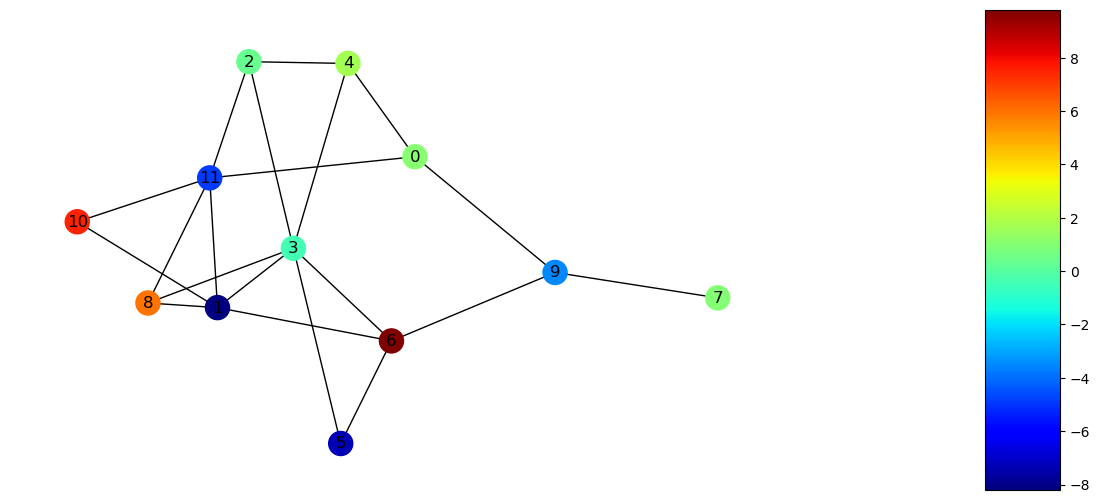

In [81]:
HFlambda = HF*eigenvalues
Hlplus1 = eigenvectors @ np.diag(HFlambda) @ eigenvectors.T @ H
vmin=np.min(Hlplus1)
vmax=np.max(Hlplus1)
fig,ax1 = plt.subplots(1,1,figsize=(10,6))
nx.draw(G,alpha=1,node_color=Hlplus1,pos=my_pose,vmin=vmin,vmax=vmax,cmap='jet', ax=ax1,with_labels = True)
cax = plt.axes([1.1, 0.1, 0.075, 0.8])
plt.colorbar( matplotlib.cm.ScalarMappable(norm=plt.Normalize(vmin=vmin,vmax=vmax), cmap='jet'), ax=ax1,orientation="vertical",cax=cax)

passe bas

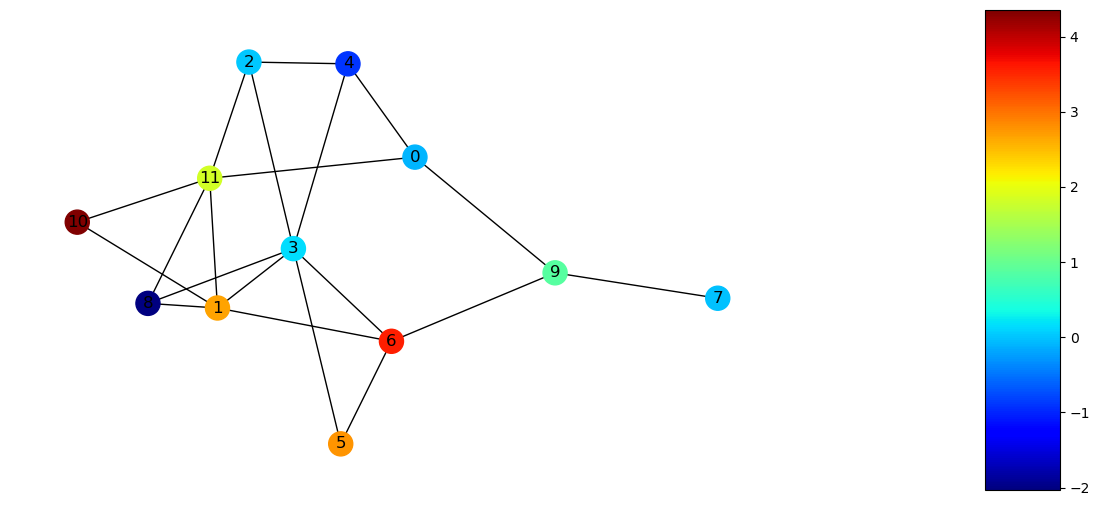

In [73]:
Hlplus2 = eigenvectors @ np.diag(LF) @ eigenvectors.T @ H
vmin=np.min(Hlplus2)
vmax=np.max(Hlplus2)
fig,ax1 = plt.subplots(1,1,figsize=(10,6))
nx.draw(G,alpha=1,node_color=Hlplus2,pos=my_pose,vmin=vmin,vmax=vmax,cmap='jet', ax=ax1,with_labels = True)
cax = plt.axes([1.1, 0.1, 0.075, 0.8])
plt.colorbar( matplotlib.cm.ScalarMappable(norm=plt.Normalize(vmin=vmin,vmax=vmax), cmap='jet'), ax=ax1,orientation="vertical",cax=cax)

Le noeuds avec le poids le plus fort diffuse de l'information à ses voisins. Comme on peut le voir sur le noeud 10 qui a la plus grande valeur, il 

Le message passing est incapable de faire du passe haut